# Setup

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fxvol.data_utils import load_csv
from fxvol.config import CURRENCIES, MODELS, MODEL_NAMES, LOSS_FNS

In [2]:
# Pictures size

plt.rcParams["figure.figsize"] = [15, 8]

# Forecasting results

In [3]:
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0)
    print(currency)
    print(res.head(5))
    print("\n")

AUD
               RMSE       MAE     QLIKE
gb_tree    0.002601  0.001847  0.089711
ols        0.002656  0.001899  0.094356
har        0.002667  0.001899  0.095283
garch11    0.002706  0.001967  0.096411
rolling50  0.002721  0.001926  0.098419


CHF
                   RMSE       MAE     QLIKE
gb_tree        0.002372  0.001598  0.114434
ols            0.002141  0.001573  0.115778
har            0.002167  0.001602  0.120480
rolling50      0.002184  0.001561  0.120493
elastic_net_1  0.002418  0.001910  0.144518


EUR
               RMSE       MAE     QLIKE
gb_tree    0.001855  0.001400  0.096292
ols        0.001843  0.001388  0.097797
garch11    0.001889  0.001475  0.100719
har        0.001867  0.001407  0.101005
rolling50  0.001874  0.001386  0.101267


GBP
               RMSE       MAE     QLIKE
gb_tree    0.002330  0.001691  0.102017
ols        0.002376  0.001727  0.105144
garch11    0.002455  0.001872  0.110678
har        0.002431  0.001752  0.111364
rolling50  0.002474  0.001774  0.1

In [4]:
fc_res = []
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0).astype(float)
    res.index.name = "model"
    res["currency"] = currency
    fc_res.append(res)

fc_res = pd.concat(fc_res)

In [7]:
fc_res_mean = fc_res.groupby("model")[LOSS_FNS].mean()
fc_res_mean = fc_res_mean.sort_values(by="QLIKE", ascending=True)

In [8]:
fc_res_mean.style.format("{:.2e}")

,MAE,RMSE,QLIKE
model,,,
gb_tree,1.67e-03,2.32e-03,1.05e-01
ols,1.68e-03,2.30e-03,1.08e-01
har,1.70e-03,2.33e-03,1.11e-01
rolling50,1.71e-03,2.38e-03,1.15e-01
garch11,1.89e-03,2.44e-03,1.19e-01
elastic_net_1,2.00e-03,2.60e-03,1.38e-01
elastic_net_1e-3,2.00e-03,2.60e-03,1.38e-01
ewma030,1.97e-03,2.71e-03,1.51e-01
rolling5,1.98e-03,2.72e-03,1.62e-01


In [20]:
fc_res_mean

,MAE,RMSE,QLIKE
model,,,
gb_tree,0.001667,0.002321,0.105285
ols,0.001678,0.002301,0.107781
har,0.001696,0.002329,0.111303
rolling50,0.001715,0.002380,0.114533
garch11,0.001886,0.002445,0.119174
elastic_net_1,0.001996,0.002604,0.137914
elastic_net_1e-3,0.001996,0.002604,0.137914
ewma030,0.001972,0.002714,0.150754
rolling5,0.001977,0.002725,0.161997


<BarContainer object of 11 artists>

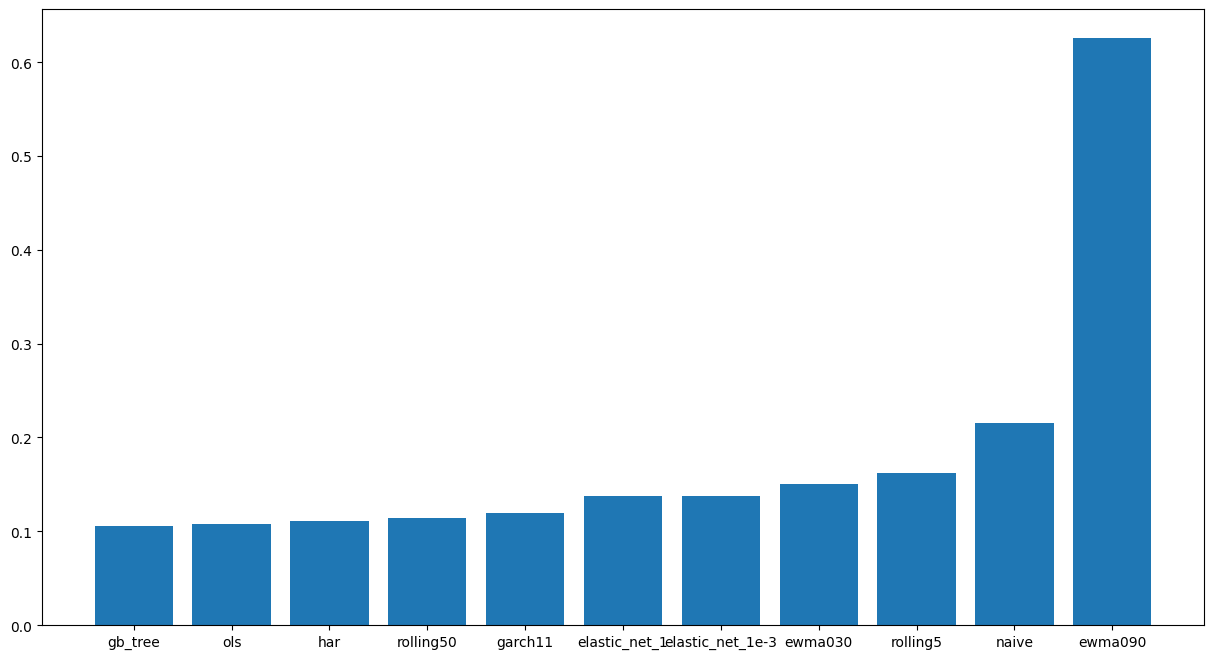

In [ ]:
plt.bar(fc_res_mean.index, fc_res_mean["QLIKE"])

In [27]:
qlikes = pd.DataFrame(index=CURRENCIES, columns=MODELS)
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0)
    qlikes.loc[currency] = res.loc[MODELS, "QLIKE"]

qlikes = qlikes.astype(float)

<Axes: >

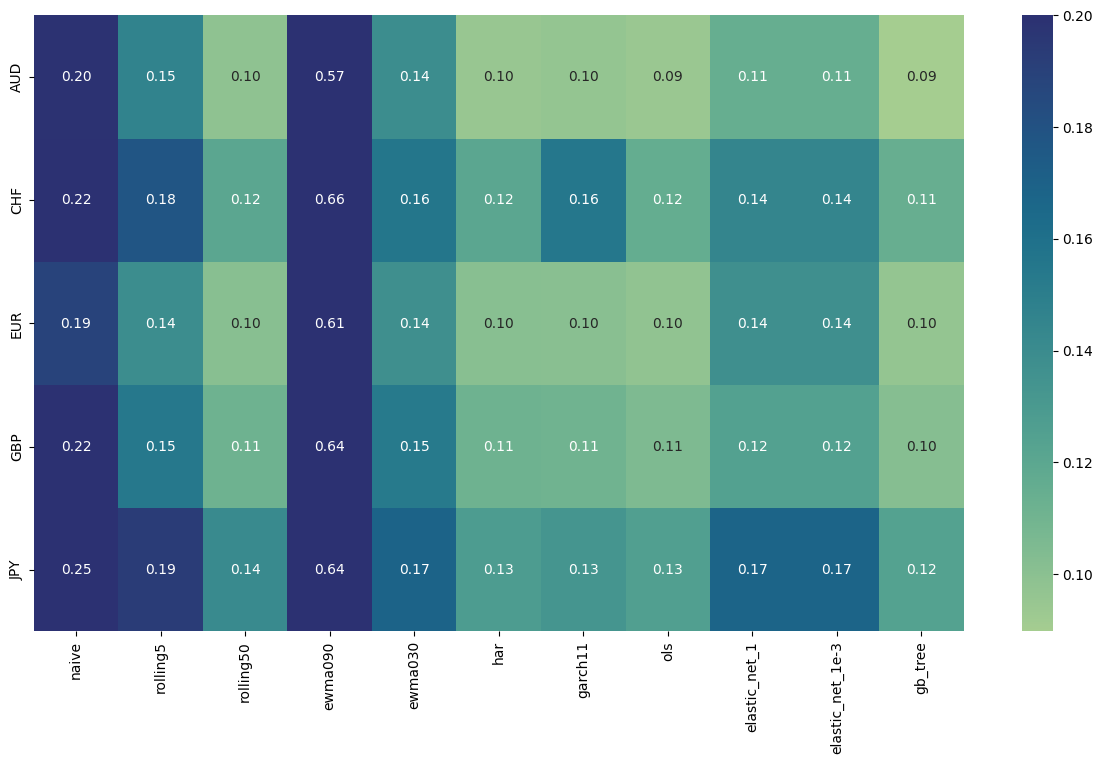

In [28]:
sns.heatmap(qlikes, annot=True, fmt=".2f", cmap="crest", vmax=0.2)

# Volatility targeting results

In [5]:
metrics = load_csv("results/summary", "metrics", index_col=0)
metrics.index.name = "model"

In [ ]:
metrics.style.format(
    {
        "ann_return": "{:.1%}",
        "ann_vol": "{:.1%}",
        "vol_error": "{:.1%}",
        "max_dd": "{:.1%}",
        "sharpe": "{:.2f}",
    }
)

,ann_return,ann_vol,vol_error,Sharpe,max_dd
model,,,,,
rolling50,-3.2%,11.1%,1.1%,-0.286236,-36.5%
har,-2.1%,10.7%,0.7%,-0.197102,-32.8%
garch11,-2.2%,9.7%,0.3%,-0.224890,-30.0%
ols,-2.5%,10.5%,0.5%,-0.233931,-32.1%
gb_tree,-1.4%,10.2%,0.2%,-0.140276,-30.9%


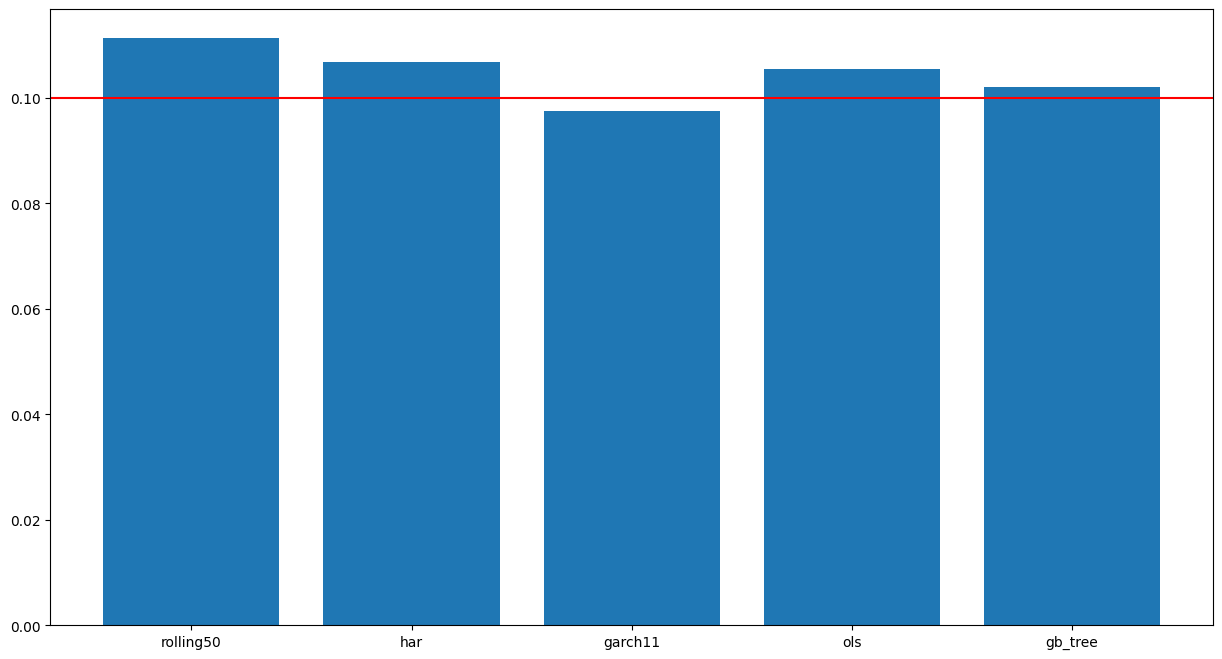

In [ ]:
plt.bar(metrics.index, metrics["ann_vol"])
plt.axhline(y=0.1, color="r")

# Equity curves

In [ ]:
equity = np.exp(log_rets.cumsum())

<Axes: xlabel='Date'>

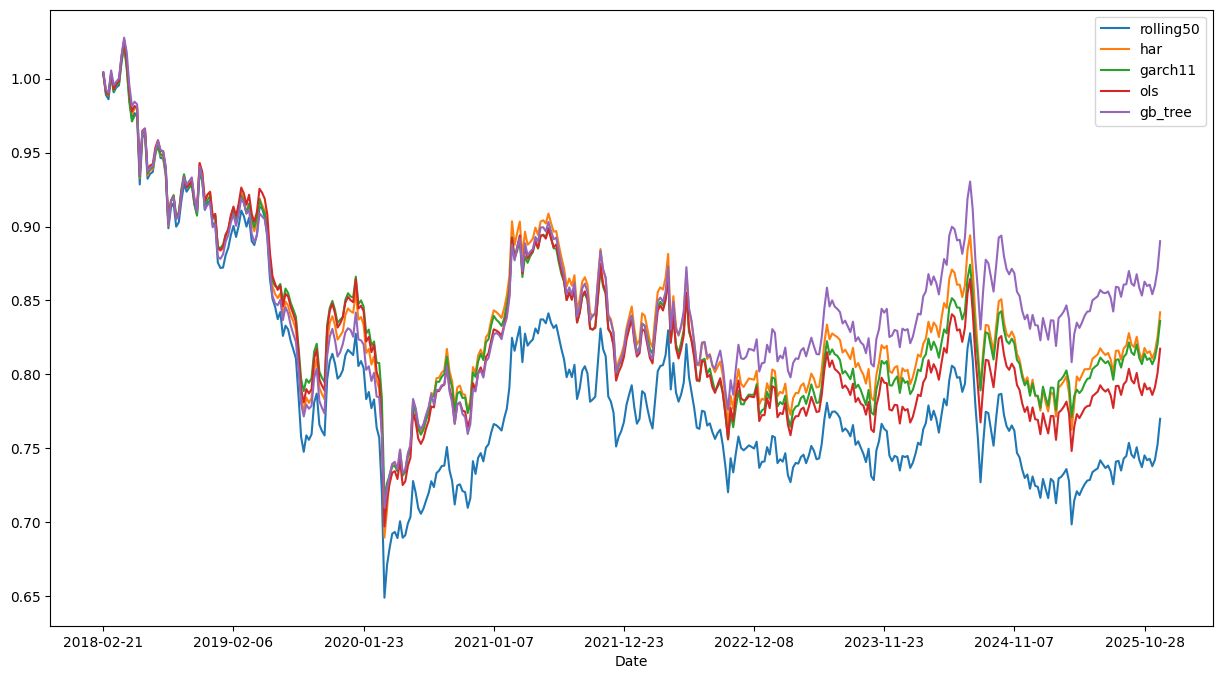

In [4]:
equity.plot()

In [ ]:
log_rets = load_csv("results/summary", "log_rets")
rolling_vol = log_rets.rolling(100).std() * np.sqrt(252 / 5)

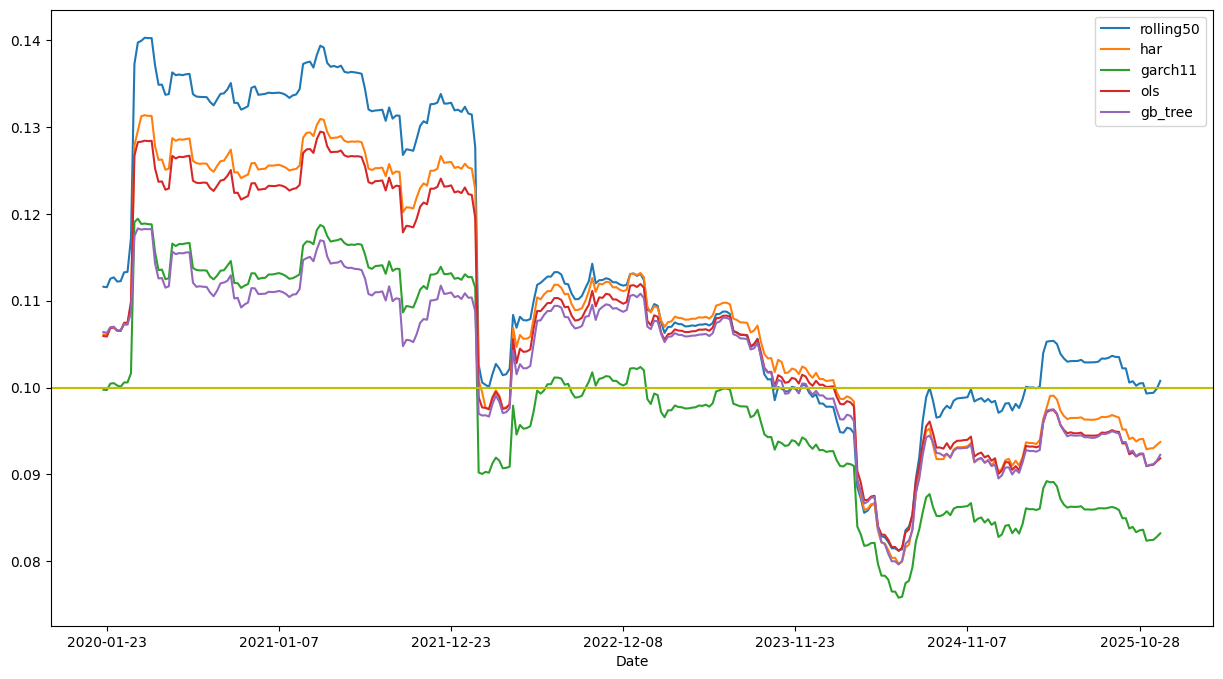

In [ ]:
rolling_vol.plot()
plt.axhline(y=0.1, color="y")

In [ ]:
df = pd.concat([equity[["gb_tree"]], fx], axis=1)

<Axes: xlabel='Date'>

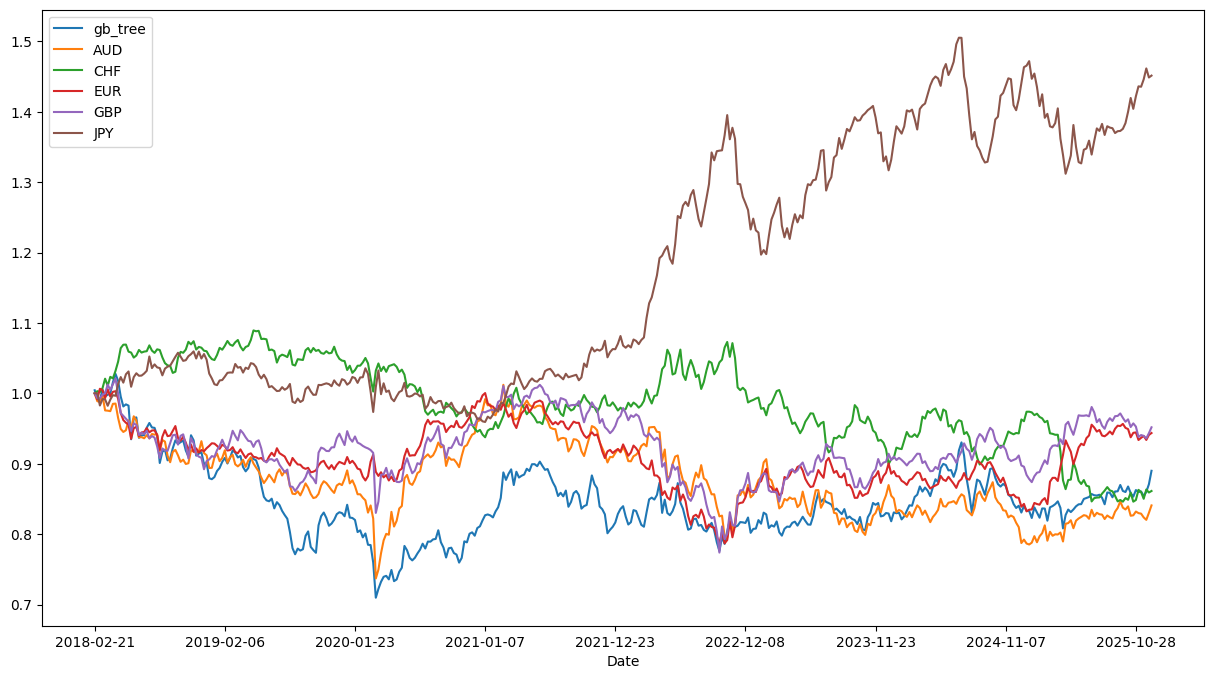

In [21]:
df.plot()

In [ ]:
lr = load_csv("data/processed", "log_returns")
lr = lr.loc[equity.index]

In [ ]:
sig = np.sqrt(252 / 5) * (lr.std())

In [30]:
sig

AUD    0.045517
CHF    0.035648
EUR    0.034408
GBP    0.039506
JPY    0.039200
dtype: float64

In [ ]:
np.sqrt(252 / 5) * (equity.std())

rolling50    0.505079
har          0.397114
garch11      0.397315
ols          0.431131
gb_tree      0.376174
dtype: float64